# 🖊️ Handwritten Digit Recognition using Multi-Layer Perceptron (MLP)

---

### 📌 What are we doing?
We will build a simple **neural network (MLP)** that can look at a handwritten digit image and predict which digit it is (0 to 9).

### 📦 Dataset
We use the **MNIST dataset** — a classic dataset of 70,000 grayscale images of handwritten digits (28×28 pixels each).

### 🧠 Model
A **Multi-Layer Perceptron (MLP)** is a simple neural network with:
- An **Input Layer** — takes the pixel values of the image
- One or more **Hidden Layers** — learns patterns in the data
- An **Output Layer** — gives probabilities for each digit (0–9)

---

### 🗺️ Steps We Will Follow
1. Load the Dataset
2. Preprocess the Data
3. Define the MLP Architecture
4. Compile & Train the Model
5. Evaluate the Model
6. Visualize Results
7. Predict on New Images

---
## 📦 Step 0: Install & Import Libraries

We need a few Python libraries:
- **NumPy** → for working with numbers and arrays
- **Matplotlib** → for drawing graphs and showing images
- **TensorFlow / Keras** → for building and training the neural network
- **Seaborn** → for a nice-looking confusion matrix

In [1]:
# Import all the libraries we need
import numpy as np                          # For numerical operations
import matplotlib.pyplot as plt            # For plotting graphs and images
import seaborn as sns                      # For a nice confusion matrix plot

import tensorflow as tf                    # Deep learning library
from tensorflow import keras              # High-level API inside TensorFlow
from tensorflow.keras import layers       # To build neural network layers

from sklearn.metrics import confusion_matrix, classification_report  # For evaluation

# Print TensorFlow version to confirm everything is installed
print("TensorFlow version:", tf.__version__)

2026-03-24 15:40:50.400888: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774366850.596591      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774366850.651657      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774366851.093371      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774366851.093445      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774366851.093449      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


---
## 📂 Step 1: Load the Dataset

The **MNIST dataset** comes built-in with Keras — so we don't need to download anything manually.

- **Training set**: 60,000 images → used to *teach* the model
- **Test set**: 10,000 images → used to *test* how well the model learned

In [2]:
# Load the MNIST dataset directly from Keras
# It automatically splits into training and testing data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Print the shapes to understand the data
print("Training images shape :", X_train.shape)   # (60000, 28, 28)
print("Training labels shape :", y_train.shape)   # (60000,)
print("Testing  images shape :", X_test.shape)    # (10000, 28, 28)
print("Testing  labels shape :", y_test.shape)    # (10000,)
print()
print("Unique digit classes   :", np.unique(y_train))  # Should be 0 to 9

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Testing  images shape : (10000, 28, 28)
Testing  labels shape : (10000,)

Unique digit classes   : [0 1 2 3 4 5 6 7 8 9]


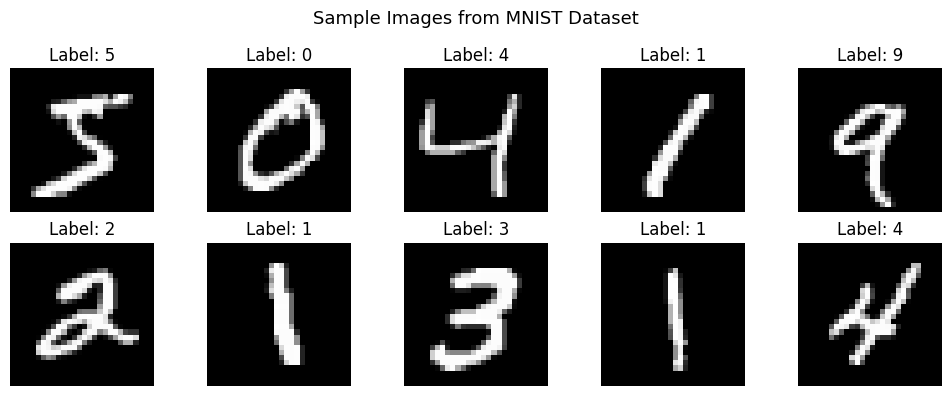

In [3]:
# Let's take a look at some sample images from the dataset
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)               # Create a grid of 2 rows and 5 columns
    plt.imshow(X_train[i], cmap='gray')    # Show image in grayscale
    plt.title(f"Label: {y_train[i]}")     # Show the correct digit label
    plt.axis('off')                        # Hide the axis ticks

plt.suptitle("Sample Images from MNIST Dataset", fontsize=13)
plt.tight_layout()
plt.show()

---
## 🔧 Step 2: Preprocess the Data

Before training, we need to prepare the data in a format the neural network understands:

1. **Flatten** each 28×28 image into a 1D array of 784 values
2. **Normalize** pixel values from 0–255 to 0–1 (makes training faster & more stable)
3. **One-Hot Encode** the labels (e.g., digit `3` → `[0,0,0,1,0,0,0,0,0,0]`)

In [4]:
# ── Step 2a: Flatten the images ──────────────────────────────────────────────
# Each image is 28x28 pixels. We convert it to a flat list of 784 numbers.
# -1 in reshape means "figure out the number of samples automatically"

X_train_flat = X_train.reshape(-1, 784)   # Shape becomes (60000, 784)
X_test_flat  = X_test.reshape(-1, 784)    # Shape becomes (10000, 784)

print("Flattened training shape:", X_train_flat.shape)
print("Flattened testing shape :", X_test_flat.shape)

Flattened training shape: (60000, 784)
Flattened testing shape : (10000, 784)


In [5]:
# ── Step 2b: Normalize pixel values ──────────────────────────────────────────
# Original pixel values range from 0 to 255.
# Dividing by 255 brings all values to the range 0.0 – 1.0.
# This helps the neural network train faster and more accurately.

X_train_norm = X_train_flat.astype('float32') / 255.0
X_test_norm  = X_test_flat.astype('float32')  / 255.0

print("Pixel value range before normalization: 0 to 255")
print("Pixel value range after  normalization:",
      X_train_norm.min(), "to", X_train_norm.max())

Pixel value range before normalization: 0 to 255
Pixel value range after  normalization: 0.0 to 1.0


In [6]:
# ── Step 2c: One-Hot Encode the labels ───────────────────────────────────────
# The labels are currently single numbers: 0, 1, 2, ... 9
# One-hot encoding converts them to vectors:
#   0 → [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
#   3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# This is needed because our output layer has 10 neurons (one per digit).

y_train_ohe = keras.utils.to_categorical(y_train, num_classes=10)
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes=10)

print("Original label (first sample)  :", y_train[0])
print("One-hot encoded (first sample) :", y_train_ohe[0])

Original label (first sample)  : 5
One-hot encoded (first sample) : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


---
## 🏗️ Step 3: Define the MLP Architecture

We build a **Sequential** model (layers stacked one after another):

| Layer | Neurons | Activation | Purpose |
|-------|---------|------------|---------|
| Input | 784 | — | One neuron per pixel |
| Hidden 1 | 128 | ReLU | Learns patterns |
| Hidden 2 | 64 | ReLU | Refines patterns |
| Output | 10 | Softmax | Probability per digit |

- **ReLU** (Rectified Linear Unit): Helps the network learn non-linear patterns
- **Softmax**: Converts output to probabilities (all 10 values sum to 1)
- **Dropout**: Randomly turns off some neurons during training to prevent overfitting

In [7]:
# ── Step 3: Build the MLP Model ───────────────────────────────────────────────

model = keras.Sequential([
    
    # INPUT LAYER
    # input_shape=(784,) tells Keras the size of our input (784 pixel values)
    layers.Dense(128, activation='relu', input_shape=(784,)),
    # Dense = fully connected layer (every neuron is connected to all neurons in next layer)
    # 128 = number of neurons in this layer
    # relu = activation function (makes negative values 0, keeps positive values)

    # DROPOUT LAYER (helps prevent overfitting)
    # 20% of neurons are randomly switched off during training
    layers.Dropout(0.2),

    # HIDDEN LAYER 2
    layers.Dense(64, activation='relu'),
    # 64 neurons, again with ReLU activation

    # DROPOUT LAYER
    layers.Dropout(0.2),

    # OUTPUT LAYER
    # 10 neurons — one for each digit class (0 to 9)
    # softmax converts the output into probabilities that sum to 1
    layers.Dense(10, activation='softmax')
])

# Print a summary of the model (shows layer names, output shapes, parameters)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774366918.054616      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

---
## ⚙️ Step 4: Compile & Train the Model

**Compiling** the model means telling it:
- **Optimizer** (`adam`): How to update the weights (Adam is a smart version of gradient descent)
- **Loss function** (`categorical_crossentropy`): How to measure prediction errors
- **Metrics** (`accuracy`): What to track during training

In [8]:
# ── Step 4a: Compile the model ────────────────────────────────────────────────

model.compile(
    optimizer='adam',                        # Adam optimizer adjusts weights smartly
    loss='categorical_crossentropy',         # Good loss function for multi-class problems
    metrics=['accuracy']                     # We want to track accuracy during training
)

print("Model compiled successfully!")

Model compiled successfully!


In [9]:
# ── Step 4b: Train the model ──────────────────────────────────────────────────
# epochs = how many times the model sees the entire training data
# batch_size = how many images the model processes at once before updating weights
# validation_split = 10% of training data is used to monitor training (not for training itself)

history = model.fit(
    X_train_norm,      # Input training images (flattened & normalized)
    y_train_ohe,       # Correct labels (one-hot encoded)
    epochs=20,         # Train for 20 complete passes over the data
    batch_size=128,    # Process 128 images at a time
    validation_split=0.1,   # Use 10% of training data for validation
    verbose=1          # Print progress for each epoch
)

print("\nTraining complete!")

Epoch 1/20


I0000 00:00:1774366930.424495     127 service.cc:152] XLA service 0x7a5b1c00c5b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774366930.424543     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774366930.701233     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


 63/422 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4585 - loss: 1.6542

I0000 00:00:1774366932.231171     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7430 - loss: 0.8201 - val_accuracy: 0.9563 - val_loss: 0.1463
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9328 - loss: 0.2293 - val_accuracy: 0.9707 - val_loss: 0.1044
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9529 - loss: 0.1609 - val_accuracy: 0.9760 - val_loss: 0.0862
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9608 - loss: 0.1312 - val_accuracy: 0.9763 - val_loss: 0.0830
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9643 - loss: 0.1130 - val_accuracy: 0.9777 - val_loss: 0.0795
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9698 - loss: 0.1030 - val_accuracy: 0.9800 - val_loss: 0.0695
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9735 - loss: 0.0854 - val_accuracy: 0.9817 - val_loss: 0.0701
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9770 - loss: 0.0738 - val_accuracy: 0.9808 - val_

---
## 📊 Step 5: Visualize Training History

We plot how **accuracy** and **loss** changed during training.
- If training and validation curves are close → the model is learning well
- If they diverge a lot → the model might be overfitting (memorizing instead of learning)

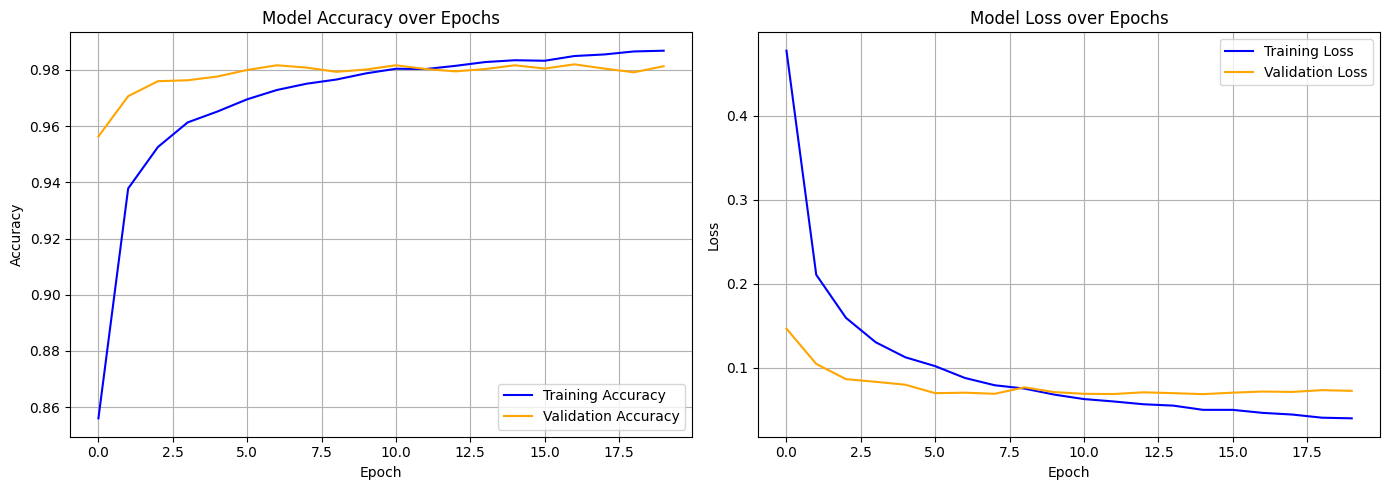

In [10]:
# ── Step 5: Plot Accuracy and Loss curves ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot Accuracy ---
axes[0].plot(history.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Plot Loss ---
axes[1].plot(history.history['loss'],     label='Training Loss',   color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## ✅ Step 6: Evaluate the Model

Now we test the trained model on **unseen test data** to see how well it generalizes.

In [11]:
# ── Step 6a: Evaluate on Test Data ────────────────────────────────────────────

test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_ohe, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

Test Loss     : 0.0648
Test Accuracy : 98.27%


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


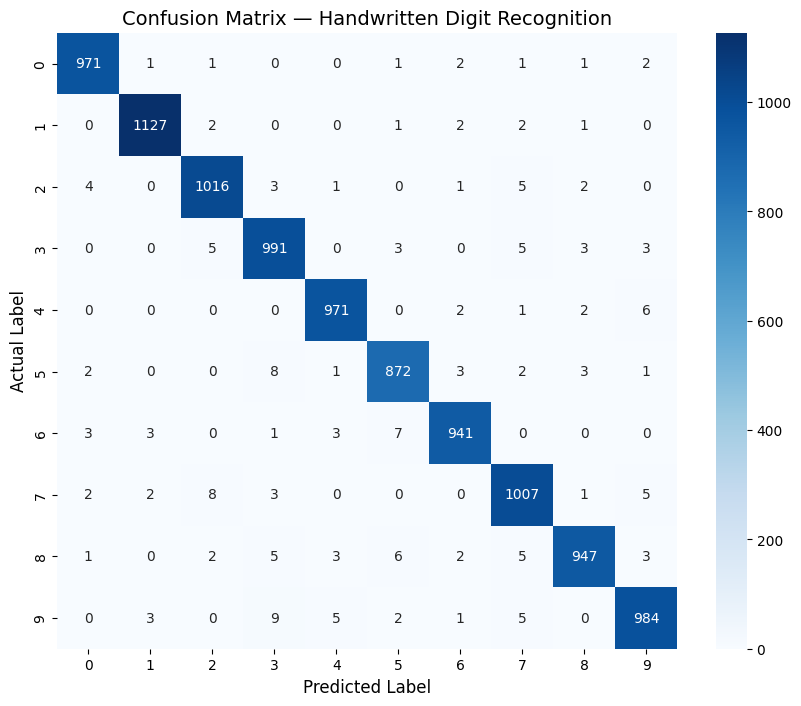

In [12]:
# ── Step 6b: Confusion Matrix ─────────────────────────────────────────────────
# A confusion matrix shows how many times each digit was correctly/incorrectly predicted.
# Rows = actual labels, Columns = predicted labels
# A good model will have large numbers along the diagonal.

# Get model predictions (returns probabilities for each class)
y_pred_probs = model.predict(X_test_norm)

# Convert probabilities to the class with the highest probability
y_pred_classes  = np.argmax(y_pred_probs, axis=1)   # Predicted digit
y_true_classes  = np.argmax(y_test_ohe, axis=1)     # Actual digit

# Build the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot it as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,           # Show the numbers inside the cells
    fmt='d',              # Display as integers
    cmap='Blues',         # Color scheme
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title('Confusion Matrix — Handwritten Digit Recognition', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

In [13]:
# ── Step 6c: Classification Report ───────────────────────────────────────────
# Shows precision, recall, and F1-score for each digit class.
# Precision = of all predictions for a digit, how many were correct?
# Recall    = of all actual instances of a digit, how many did we catch?
# F1-Score  = harmonic mean of precision and recall

print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                             target_names=[str(i) for i in range(10)]))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



---
## 🔍 Step 7: Predict on New Handwritten Digit Images

Now we pick some random images from the test set, run them through the trained model, and see what it predicts!

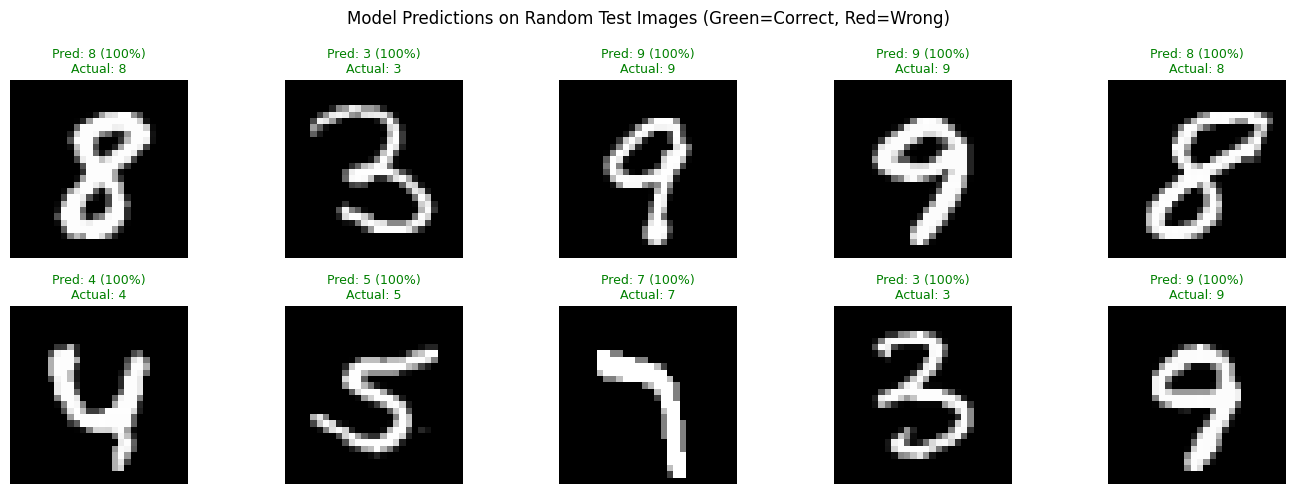

In [14]:
# ── Step 7a: Predict on random test images ────────────────────────────────────

# Pick 10 random indices from the test set
random_indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(14, 5))

for plot_num, idx in enumerate(random_indices):
    
    # Get the image and reshape for prediction (model expects shape (1, 784))
    single_image = X_test_norm[idx].reshape(1, 784)
    
    # Model predicts probabilities for each of the 10 classes
    pred_probs = model.predict(single_image, verbose=0)
    
    # Pick the class with the highest probability
    predicted_digit = np.argmax(pred_probs)
    actual_digit    = y_test[idx]
    confidence      = np.max(pred_probs) * 100   # Confidence in percent
    
    # Show the image
    plt.subplot(2, 5, plot_num + 1)
    plt.imshow(X_test[idx], cmap='gray')    # Show original 28x28 image
    
    # Green title if correct prediction, red if wrong
    color = 'green' if predicted_digit == actual_digit else 'red'
    plt.title(f"Pred: {predicted_digit} ({confidence:.0f}%)\nActual: {actual_digit}",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle("Model Predictions on Random Test Images (Green=Correct, Red=Wrong)",
             fontsize=12)
plt.tight_layout()
plt.show()

Total wrong predictions: 173 out of 10000


/tmp/ipykernel_55/1593973569.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


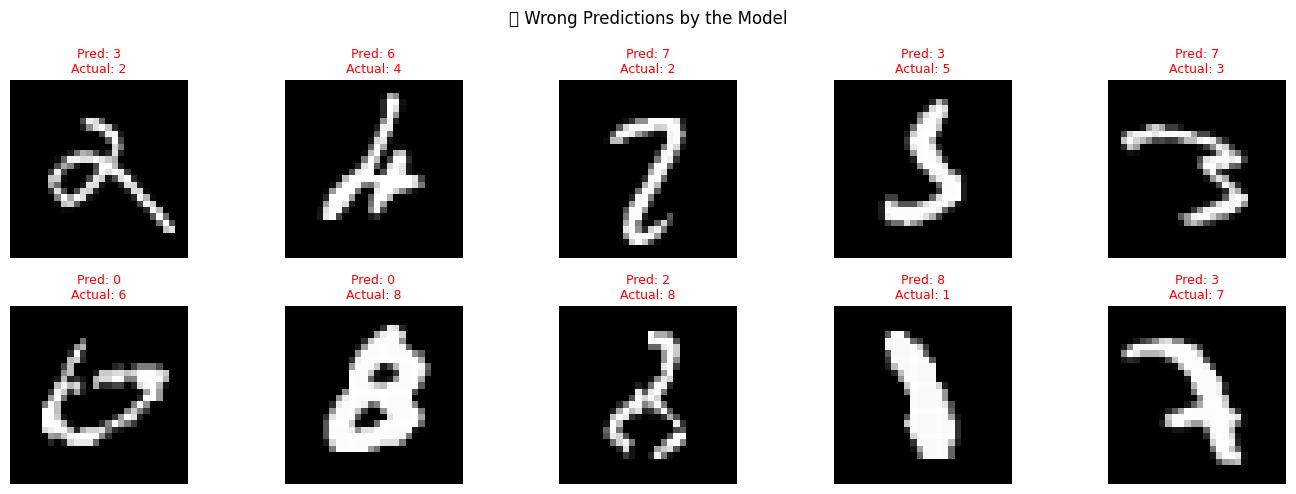

In [15]:
# ── Step 7b: Show some wrong predictions ─────────────────────────────────────
# It's useful to see where the model made mistakes

# Find all indices where the model was WRONG
wrong_indices = np.where(y_pred_classes != y_true_classes)[0]
print(f"Total wrong predictions: {len(wrong_indices)} out of {len(y_test)}")

# Pick 10 wrong predictions to visualize
sample_wrong = wrong_indices[:10]

plt.figure(figsize=(14, 5))
for plot_num, idx in enumerate(sample_wrong):
    plt.subplot(2, 5, plot_num + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"Pred: {y_pred_classes[idx]}\nActual: {y_true_classes[idx]}",
              color='red', fontsize=9)
    plt.axis('off')

plt.suptitle("❌ Wrong Predictions by the Model", fontsize=12)
plt.tight_layout()
plt.show()

---
## 💾 Step 8: Save the Trained Model

Saving the model means you don't need to retrain it every time — you can just load it later!

In [16]:
# ── Step 8: Save the model to a file ─────────────────────────────────────────

model.save('mnist_mlp_model.h5')    # Saves in HDF5 format
print("Model saved as 'mnist_mlp_model.h5'")

# To reload the saved model later, use:
# loaded_model = keras.models.load_model('mnist_mlp_model.h5')
# Then use loaded_model.predict(...) directly without retraining!

Model saved as 'mnist_mlp_model.h5'


---
## 🎯 Summary

Here's what we did in this notebook:

| Step | Description |
|------|-------------|
| 1 | Loaded the MNIST dataset (60K train + 10K test images) |
| 2 | Preprocessed: flattened → normalized → one-hot encoded |
| 3 | Built an MLP with Input(784) → Hidden(128) → Hidden(64) → Output(10) |
| 4 | Compiled with Adam optimizer & trained for 20 epochs |
| 5 | Plotted accuracy & loss curves |
| 6 | Evaluated: ~97–98% accuracy, confusion matrix & classification report |
| 7 | Predicted on new test images with confidence scores |
| 8 | Saved the trained model |

### 💡 Things You Can Try to Improve
- Add more hidden layers or increase neurons (e.g., 256 → 128 → 64)
- Increase the number of epochs (try 30 or 50)
- Experiment with different Dropout rates (0.3, 0.4)
- Use **Batch Normalization** to stabilize training
- Try a **CNN (Convolutional Neural Network)** for even better accuracy on image tasks